# Logical CX fault-tolerant scaling, Pauli learning, and PEC robustness


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import logical_csb as sq

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)


## Settings


In [2]:
N_JOBS = -1
BASE_SEED = 1234

MIN_EC_ROUNDS = 2
MAX_EC_ROUNDS = 4
DECODER_CACHE = Path("steane_flag_decoder_stabilizer_max4.pkl")

CIRCUIT_OPTIONS = {
    "prep_gates_noisy": True,
    "prep_qec_after_gate": True,
    "measurement_basis_gates_noisy": True,
    "qec_after_each_logical_gate": True,
    "fallback_on_unverified": True,
}

TWO_QUBIT_FACTOR = 2.0
FINAL_MEAS_FACTOR = 1.0

FT_NOISE_REP_SCHEDULE = [
    {"p": 1e-5, "rep": 10001},
    {"p": 3e-5, "rep": 1001},
    {"p": 1e-4, "rep": 101},
    {"p": 3e-4, "rep": 9},
    {"p": 1e-3, "rep": 1},
]
FT_CSB_STEPS = list(range(13))
FT_CSB_SHOTS = 1000
FT_CSB_CHUNK_SHOTS = 100
FT_N_REPEATS = 10
FT_FIT_MAX_P = 1e-3

PEC_PHYSICAL_NOISE_STRENGTH = 3e-4
PEC_CSB_STEPS = list(range(13))
PEC_CSB_REP = 9
PEC_CSB_SHOTS = 1000
PEC_CSB_CHUNK_SHOTS = 100
PEC_N_REPEATS = 10
PEC_FORWARD_DEPTHS = [4, 8, 12, 16, 24]
PEC_SEQUENCES_PER_DEPTH = 20
NOISY_SHOTS_PER_SEQUENCE = 10000
PEC_SHOTS_PER_SEQUENCE = 10000
PEC_CHUNK_SHOTS = 250
PEC_LOCAL_GATE_SET = ["I", "RX90", "RY90", "RZ90"]


def make_noise(p_phys):
    return sq.make_homogeneous_noise(
        strength=float(p_phys),
        two_qubit_factor=TWO_QUBIT_FACTOR,
        final_meas_factor=FINAL_MEAS_FACTOR,
    )


## Decoder and Numba warm-up


In [3]:
decoder = sq.get_or_build_decoder(
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=True,
)


Loaded verified flagged Steane EC decoder.
  decoder bins     = 445


# Part I. Logical-CX fault-tolerant scaling


In [4]:
ft = sq.run_cx_ft_scaling(
    decoder=decoder,
    options=CIRCUIT_OPTIONS,
    noise_rep_schedule=FT_NOISE_REP_SCHEDULE,
    steps=FT_CSB_STEPS,
    shots=FT_CSB_SHOTS,
    chunk_shots=FT_CSB_CHUNK_SHOTS,
    n_repeats=FT_N_REPEATS,
    fit_max_p=FT_FIT_MAX_P,
    seed=BASE_SEED,
    n_jobs=N_JOBS,
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    two_qubit_factor=TWO_QUBIT_FACTOR,
    final_meas_factor=FINAL_MEAS_FACTOR,
    verbose=True,
)

cx_ft_csb_df = ft["csb_df"]
cx_ft_raw_df = ft["raw_df"]
cx_ft_summary_df = ft["summary_df"]
cx_ft_fit_df = ft["fit_df"]

display(cx_ft_summary_df)
display(cx_ft_fit_df)


FT p=1e-05 repeat 1/10
FT p=1e-05 repeat 2/10
FT p=1e-05 repeat 3/10
FT p=1e-05 repeat 4/10
FT p=1e-05 repeat 5/10
FT p=1e-05 repeat 6/10
FT p=1e-05 repeat 7/10
FT p=1e-05 repeat 8/10
FT p=1e-05 repeat 9/10
FT p=1e-05 repeat 10/10
FT p=3e-05 repeat 1/10
FT p=3e-05 repeat 2/10
FT p=3e-05 repeat 3/10
FT p=3e-05 repeat 4/10
FT p=3e-05 repeat 5/10
FT p=3e-05 repeat 6/10
FT p=3e-05 repeat 7/10
FT p=3e-05 repeat 8/10
FT p=3e-05 repeat 9/10
FT p=3e-05 repeat 10/10
FT p=0.0001 repeat 1/10
FT p=0.0001 repeat 2/10
FT p=0.0001 repeat 3/10
FT p=0.0001 repeat 4/10
FT p=0.0001 repeat 5/10
FT p=0.0001 repeat 6/10
FT p=0.0001 repeat 7/10
FT p=0.0001 repeat 8/10
FT p=0.0001 repeat 9/10
FT p=0.0001 repeat 10/10
FT p=0.0003 repeat 1/10
FT p=0.0003 repeat 2/10
FT p=0.0003 repeat 3/10
FT p=0.0003 repeat 4/10
FT p=0.0003 repeat 5/10
FT p=0.0003 repeat 6/10
FT p=0.0003 repeat 7/10
FT p=0.0003 repeat 8/10
FT p=0.0003 repeat 9/10
FT p=0.0003 repeat 10/10
FT p=0.001 repeat 1/10
FT p=0.001 repeat 2/10
FT p=0.001

,physical_noise_strength,n_repeats,rep,max_depth,loss_IX_mean,loss_IX_std,loss_ZI_mean,loss_ZI_std,loss_ZX_mean,loss_ZX_std,loss_XY_mean,loss_XY_std,loss_A_mean,loss_A_std,loss_C_mean,loss_C_std,abs_delta_A_mean,abs_delta_A_std,abs_delta_C_mean,abs_delta_C_std,process_fidelity_mean,process_fidelity_std,process_infidelity_mean,process_infidelity_std,mean_unverified_rate_mean,mean_unverified_rate_std,mean_ec_rounds_mean,mean_ec_rounds_std
0,0.00001,10,10001,120012,0.000009,2.013479e-07,0.000009,1.786855e-07,0.000018,0.000001,0.000027,0.000002,0.000018,7.870443e-07,0.000018,7.591963e-07,7.738038e-07,4.675118e-07,6.768520e-07,4.986645e-07,0.999982,5.090859e-07,0.000018,5.090859e-07,0.000010,1.028623e-06,1.848596,7.236744e-07
1,0.00003,10,1001,12012,0.000078,2.956476e-06,0.000078,1.392606e-06,0.000158,0.000008,0.000245,0.000006,0.000161,6.865505e-06,0.000163,6.877606e-06,2.663423e-06,2.891784e-06,8.855080e-06,5.562370e-06,0.999838,2.516745e-06,0.000162,2.516745e-06,0.000090,9.767518e-07,1.853360,2.641978e-06
2,0.00010,10,101,1212,0.000865,2.862323e-05,0.000858,3.198925e-05,0.001681,0.000054,0.002584,0.000070,0.001709,6.183703e-05,0.001727,5.085422e-05,5.249549e-05,4.719146e-05,7.272241e-05,6.763239e-05,0.998282,2.376959e-05,0.001718,2.376959e-05,0.001000,1.783643e-05,1.869042,2.575734e-05
3,0.00030,10,9,108,0.007011,2.124211e-04,0.007073,2.799937e-04,0.014164,0.000389,0.020764,0.000563,0.014141,4.685828e-04,0.014091,6.324195e-04,5.883972e-04,2.802662e-04,7.323308e-04,4.787411e-04,0.985985,2.645756e-04,0.014015,2.645756e-04,0.008129,5.145813e-05,1.900842,6.202917e-05
4,0.00100,10,1,12,0.063360,2.053245e-03,0.064083,2.130408e-03,0.120062,0.003060,0.167040,0.005663,0.116474,6.455972e-03,0.118904,3.620150e-03,6.000852e-03,5.058280e-03,6.858756e-03,4.557898e-03,0.883926,2.312665e-03,0.116074,2.312665e-03,0.065646,2.014022e-04,1.931147,1.651635e-04


,fit_max_noise_strength,num_fit_points,quadratic_coefficient_A,free_power_slope,free_power_prefactor
0,0.001,5,154958.605945,1.909389,68850.696582


## FT-scaling figure


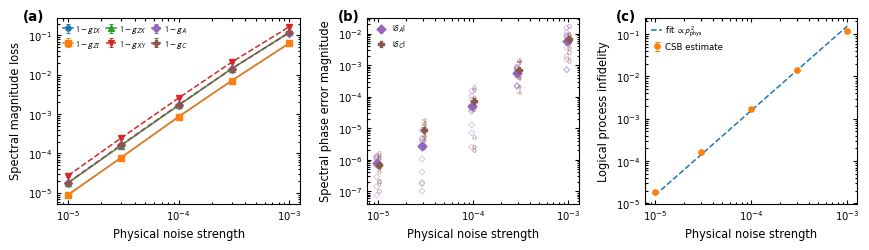

In [5]:
def positive_log_error(mean, std):
    """
    Keep the lower endpoint positive on a logarithmic axis.
    The reported mean and standard deviation are not changed.
    """
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)
    std = np.where(np.isfinite(std), std, 0.0)

    lower = np.minimum(std, 0.95 * mean)
    return np.vstack([lower, std])


def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        length=3.0,
        width=0.8,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        length=1.8,
    )


def panel_label(ax, text):
    ax.text(
        -0.14,
        1.045,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="top",
    )


# ============================================================
# Data
# ============================================================

p_array = cx_ft_summary_df[
    "physical_noise_strength"
].to_numpy(dtype=float)

spectral_modes = [
    "IX",
    "ZI",
    "ZX",
    "XY",
    "A",
    "C",
]

spectral_labels = {
    "IX": r"$1-g_{IX}$",
    "ZI": r"$1-g_{ZI}$",
    "ZX": r"$1-g_{ZX}$",
    "XY": r"$1-g_{XY}$",
    "A": r"$1-g_A$",
    "C": r"$1-g_C$",
}

spectral_markers = {
    "IX": "o",
    "ZI": "s",
    "ZX": "^",
    "XY": "v",
    "A": "D",
    "C": "P",
}

spectral_linestyles = {
    "IX": "-",
    "ZI": "-",
    "ZX": "-",
    "XY": "--",
    "A": "--",
    "C": "--",
}


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Arial",
            "Helvetica",
            "DejaVu Sans",
        ],
        "mathtext.fontset": "stixsans",
        "font.size": 7.2,
        "axes.labelsize": 8.2,
        "xtick.labelsize": 7.2,
        "ytick.labelsize": 7.2,
        "legend.fontsize": 6.2,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.1,
        "lines.markersize": 3.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(8.6, 2.55),
        gridspec_kw={
            "width_ratios": [1.15, 1.0, 1.0],
        },
    )

    # ========================================================
    # (a) Spectral magnitude losses
    # ========================================================

    ax = axes[0]

    for mode in spectral_modes:
        mean = cx_ft_summary_df[
            f"loss_{mode}_mean"
        ].to_numpy(dtype=float)

        std = cx_ft_summary_df[
            f"loss_{mode}_std"
        ].to_numpy(dtype=float)

        keep = (
            np.isfinite(p_array)
            & np.isfinite(mean)
            & (p_array > 0)
            & (mean > 0)
        )

        ax.errorbar(
            p_array[keep],
            mean[keep],
            yerr=positive_log_error(
                mean[keep],
                std[keep],
            ),
            marker=spectral_markers[mode],
            linestyle=spectral_linestyles[mode],
            capsize=1.6,
            capthick=0.7,
            elinewidth=0.65,
            label=spectral_labels[mode],
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Physical noise strength")
    ax.set_ylabel("Spectral magnitude loss")

    ax.legend(
        loc="upper left",
        frameon=False,
        ncol=3,
        columnspacing=0.50,
        handlelength=1.20,
        handletextpad=0.28,
        borderaxespad=0.25,
        labelspacing=0.30,
    )

    format_axis(ax)
    panel_label(ax, "(a)")

        # ========================================================
    # (b) Fitted phase-shift magnitudes
    # ========================================================
    
    ax = axes[1]
    
    colors = mpl.rcParams[
        "axes.prop_cycle"
    ].by_key()["color"]
    
    
    angle_specs = [
        (
            "abs_delta_A",
            r"$|\delta_A|$",
            spectral_markers["A"],
            colors[spectral_modes.index("A")],
            0.972,
        ),
        (
            "abs_delta_C",
            r"$|\delta_C|$",
            spectral_markers["C"],
            colors[spectral_modes.index("C")],
            1.028,
        ),
    ]
    
    for (
        column,
        label,
        marker,
        color,
        x_factor,
    ) in angle_specs:
    
        raw_x = (
            cx_ft_raw_df[
                "physical_noise_strength"
            ].to_numpy(dtype=float)
            * x_factor
        )
    
        raw_y = cx_ft_raw_df[
            column
        ].to_numpy(dtype=float)
    
        raw_keep = (
            np.isfinite(raw_x)
            & np.isfinite(raw_y)
            & (raw_x > 0)
            & (raw_y > 0)
        )
    
        ax.scatter(
            raw_x[raw_keep],
            raw_y[raw_keep],
            s=9,
            marker=marker,
            facecolors="none",
            edgecolors=color,
            linewidths=0.55,
            alpha=0.45,
            zorder=1,
        )
    
        # ----------------------------------------------------
        # Mean values
        # Filled markers, no connecting line
        # ----------------------------------------------------
        mean = cx_ft_summary_df[
            f"{column}_mean"
        ].to_numpy(dtype=float)
    
        keep = (
            np.isfinite(p_array)
            & np.isfinite(mean)
            & (p_array > 0)
            & (mean > 0)
        )
    
        ax.scatter(
            p_array[keep] * x_factor,
            mean[keep],
            s=20,
            marker=marker,
            color=color,
            label=label,
            zorder=3,
        )
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.set_xlabel("Physical noise strength")
    ax.set_ylabel("Spectral phase error magnitude")
    
    ax.legend(
        loc="upper left",
        frameon=False,
        handletextpad=0.30,
        borderaxespad=0.25,
    )
    
    format_axis(ax)
    panel_label(ax, "(b)")
    

    # ========================================================
    # (c) Logical process infidelity
    # ========================================================

    ax = axes[2]

    process_infidelity = cx_ft_summary_df[
        "process_infidelity_mean"
    ].to_numpy(dtype=float)

    process_infidelity_std = cx_ft_summary_df[
        "process_infidelity_std"
    ].to_numpy(dtype=float)

    keep = (
        np.isfinite(p_array)
        & np.isfinite(process_infidelity)
        & (p_array > 0)
        & (process_infidelity > 0)
    )

    quadratic_A = float(
        cx_ft_fit_df[
            "quadratic_coefficient_A"
        ].iloc[0]
    )

    p_dense = np.logspace(
        np.log10(np.min(p_array[keep])),
        np.log10(np.max(p_array[keep])),
        400,
    )

    # Plot fit first so legend order matches the reference figure
    ax.plot(
        p_dense,
        quadratic_A * p_dense**2,
        linestyle="--",
        label=rf"fit $\propto p_{{\rm phys}}^2$",
        zorder=1,
    )

    ax.errorbar(
        p_array[keep],
        process_infidelity[keep],
        yerr=positive_log_error(
            process_infidelity[keep],
            process_infidelity_std[keep],
        ),
        marker="o",
        linestyle="none",
        capsize=1.8,
        capthick=0.7,
        elinewidth=0.65,
        label="CSB estimate",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Physical noise strength")
    ax.set_ylabel("Logical process infidelity")

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.30,
        handletextpad=0.30,
        borderaxespad=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(c)")

    fig.subplots_adjust(
        left=0.065,
        right=0.995,
        bottom=0.225,
        top=0.955,
        wspace=0.30,
    )

    fig.savefig(
        "cx_ft_scaling.pdf",
        bbox_inches="tight",
    )

    plt.show()

# Part II. Fixed-noise Pauli learning and PEC robustness


In [6]:
pec = sq.run_cx_pauli_model_comparison_workflow(
    decoder=decoder,
    noise=make_noise(PEC_PHYSICAL_NOISE_STRENGTH),
    options=CIRCUIT_OPTIONS,
    csb_steps=PEC_CSB_STEPS,
    csb_rep=PEC_CSB_REP,
    csb_shots=PEC_CSB_SHOTS,
    csb_chunk_shots=PEC_CSB_CHUNK_SHOTS,
    n_repeats=PEC_N_REPEATS,
    depths=PEC_FORWARD_DEPTHS,
    sequences_per_depth=PEC_SEQUENCES_PER_DEPTH,
    noisy_shots_per_sequence=NOISY_SHOTS_PER_SEQUENCE,
    pec_shots_per_sequence=PEC_SHOTS_PER_SEQUENCE,
    local_gate_set=PEC_LOCAL_GATE_SET,
    seed=BASE_SEED + 700_000,
    n_jobs=N_JOBS,
    pec_chunk_shots=PEC_CHUNK_SHOTS,
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=True,
)

cx_pec_spectra_summary_df = pec["spectra_summary_df"]
cx_pec_tau_summary_df = pec["tau_summary_df"]
cx_pec_summary_df = pec["pec_summary_df"]
cx_pec_model_comparison_summary_df = pec["model_comparison_summary_df"]
cx_pec_model_probability_summary_df = pec["model_probability_summary_df"]
cx_pec_model_diagnostics_summary_df = pec["model_diagnostics_summary_df"]

display(cx_pec_spectra_summary_df)
display(cx_pec_tau_summary_df)
display(cx_pec_model_diagnostics_summary_df)


PEC repeat 1/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 2/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 3/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 4/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 5/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 6/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 7/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maximum-correlated']
PEC repeat 8/10
CX Pauli-model PEC comparison [4, 8, 12, 16, 24] ['Moore-Penrose', 'Minimum-correlated', 'Maxim

,mode,g_mean,g_std,delta_theta_mean,delta_theta_std
0,A,0.985982,0.000393,-0.000280,0.000516
1,C,0.985912,0.000593,-0.000003,0.000807
2,IX,0.992936,0.000235,NaN,0.000000
3,XY,0.978937,0.000414,NaN,0.000000
4,ZI,0.992877,0.000358,NaN,0.000000
5,ZX,0.985703,0.000351,NaN,0.000000


,pauli,tau_projected_mean,tau_projected_std,probability_projected_mean,probability_projected_std,inverse_q_mean,inverse_q_std
0,II,1.000000,1.613117e-16,0.985914,0.000293,1.014318,0.000303
1,IX,0.992921,2.408527e-04,0.003455,0.000156,-0.003548,0.000161
2,IY,0.985884,2.793583e-04,0.000877,0.000031,-0.000889,0.000032
3,IZ,0.985884,2.793583e-04,0.000877,0.000031,-0.000889,0.000032
4,XI,0.985815,5.046816e-04,0.000884,0.000037,-0.000897,0.000038
5,XX,0.985815,5.046816e-04,0.000884,0.000037,-0.000897,0.000038
6,XY,0.979035,4.435414e-04,0.000008,0.000011,-0.000002,0.000011
7,XZ,0.979035,4.435414e-04,0.000008,0.000011,-0.000002,0.000011
8,YI,0.985815,5.046816e-04,0.000884,0.000037,-0.000897,0.000038
9,YX,0.985815,5.046816e-04,0.000884,0.000037,-0.000897,0.000038


,model,p_II_mean,p_II_std,total_nonidentity_probability_mean,total_nonidentity_probability_std,single_block_probability_mean,single_block_probability_std,two_block_correlated_probability_mean,two_block_correlated_probability_std,p_XI_mean,p_XI_std,p_XX_mean,p_XX_std,p_IY_mean,p_IY_std,p_ZY_mean,p_ZY_std,gamma_per_composite_layer_mean,gamma_per_composite_layer_std,max_abs_CSB_spectrum_difference_mean,max_abs_CSB_spectrum_difference_std
0,Maximum-correlated,0.985914,0.000293,0.014086,0.000293,0.006945,0.000238,0.007141,0.000271,0.000000,0.000000,0.001768,0.000074,0.000000,0.000000,0.001753,0.000063,1.028803,0.000601,7.943655e-10,1.706184e-13
1,Minimum-correlated,0.985914,0.000293,0.014086,0.000293,0.013988,0.000269,0.000098,0.000095,0.001768,0.000074,0.000000,0.000000,0.001753,0.000063,0.000000,0.000000,1.028803,0.000601,7.943655e-10,1.705324e-13
2,Moore-Penrose,0.985914,0.000293,0.014086,0.000293,0.010466,0.000230,0.003619,0.000173,0.000884,0.000037,0.000884,0.000037,0.000877,0.000031,0.000877,0.000031,1.028694,0.000592,1.332268e-16,1.020225e-16


## PEC comparison across CSB-equivalent Pauli models

The Moore--Penrose, minimum-correlated, and maximum-correlated channels have
the same six measured CX-CSB spectral combinations and differ only along the
two unresolved Pauli-fidelity directions.


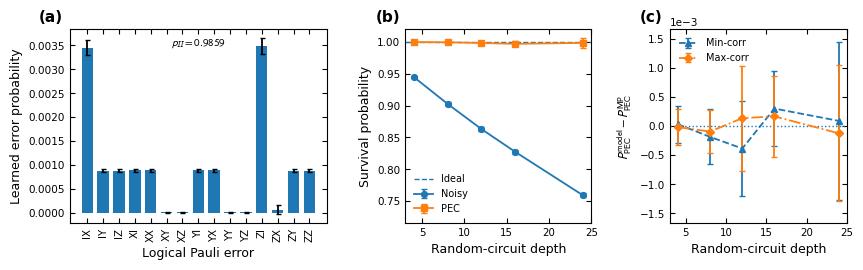

In [7]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


# ============================================================
# Data
# ============================================================

prob_summary = cx_pec_model_probability_summary_df.copy()
comparison_summary = cx_pec_model_comparison_summary_df.copy()
comparison_repeats = pec["model_comparison_repeats_df"].copy()

pauli_order = [
    "IX", "IY", "IZ",
    "XI", "XX", "XY", "XZ",
    "YI", "YX", "YY", "YZ",
    "ZI", "ZX", "ZY", "ZZ",
]


# ============================================================
# Panel (a): Moore-Penrose Pauli probabilities
# ============================================================

mp_prob = (
    prob_summary[
        (prob_summary["model"] == "Moore-Penrose")
        & (prob_summary["pauli"].isin(pauli_order))
    ]
    .set_index("pauli")
    .reindex(pauli_order)
)

p_mean = mp_prob["probability_mean"].to_numpy(float)
p_std = (
    mp_prob["probability_std"]
    .fillna(0.0)
    .to_numpy(float)
)

pII = prob_summary[
    (prob_summary["model"] == "Moore-Penrose")
    & (prob_summary["pauli"] == "II")
]["probability_mean"]

pII = float(pII.iloc[0])


# ============================================================
# Panel (b): standard PEC result
# ============================================================

def get_curve(name):
    sub = (
        comparison_summary[
            comparison_summary["model"] == name
        ]
        .sort_values("depth")
    )
    return (
        sub["depth"].to_numpy(float),
        sub["survival_probability_mean"].to_numpy(float),
        sub["survival_probability_std"]
        .fillna(0.0)
        .to_numpy(float),
    )


depth_noisy, noisy_mean, noisy_std = get_curve("Noisy")
depth_mp, mp_mean, mp_std = get_curve("Moore-Penrose")


# ============================================================
# Panel (c): paired null-space comparison
# ============================================================

pivot = (
    comparison_repeats[
        comparison_repeats["model"].isin(
            [
                "Moore-Penrose",
                "Minimum-correlated",
                "Maximum-correlated",
            ]
        )
    ]
    .pivot(
        index=["repeat_id", "depth"],
        columns="model",
        values="survival_probability",
    )
    .reset_index()
)

pivot["min_minus_mp"] = (
    pivot["Minimum-correlated"]
    - pivot["Moore-Penrose"]
)

pivot["max_minus_mp"] = (
    pivot["Maximum-correlated"]
    - pivot["Moore-Penrose"]
)

delta = (
    pivot.groupby("depth", as_index=False)
    .agg(
        min_mean=("min_minus_mp", "mean"),
        min_std=("min_minus_mp", "std"),
        max_mean=("max_minus_mp", "mean"),
        max_std=("max_minus_mp", "std"),
    )
)

delta["min_std"] = delta["min_std"].fillna(0.0)
delta["max_std"] = delta["max_std"].fillna(0.0)


# ============================================================
# Figure
# ============================================================

with mpl.rc_context(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.fontset": "stixsans",
        "font.size": 8.0,
        "axes.labelsize": 9.0,
        "xtick.labelsize": 7.3,
        "ytick.labelsize": 7.5,
        "legend.fontsize": 7.0,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.3,
        "lines.markersize": 4.2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(8.4, 2.8),
        gridspec_kw={
            "width_ratios": [1.45, 1.05, 1.0],
        },
    )

    # ========================================================
    # (a) Learned Pauli distribution
    # ========================================================

    ax = axes[0]

    x = np.arange(len(pauli_order))

    ax.bar(
        x,
        p_mean,
        yerr=p_std,
        capsize=1.8,
        width=0.72,
        linewidth=0.5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        pauli_order,
        rotation=90,
    )

    ax.set_xlabel("Logical Pauli error")
    ax.set_ylabel("Learned error probability")

    ax.text(
        0.50,
        0.96,
        rf"$p_{{II}}={pII:.4f}$",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=8,
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.text(
        -0.12,
        1.04,
        "(a)",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
    )


    # ========================================================
    # (b) PEC performance
    # ========================================================

    ax = axes[1]

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1.0,
        label="Ideal",
    )

    ax.errorbar(
        depth_noisy,
        noisy_mean,
        yerr=noisy_std,
        marker="o",
        linestyle="-",
        capsize=2,
        label="Noisy",
    )

    ax.errorbar(
        depth_mp,
        mp_mean,
        yerr=mp_std,
        marker="s",
        linestyle="-",
        capsize=2,
        label="PEC",
    )

    ax.set_xlabel("Random-circuit depth")
    ax.set_ylabel("Survival probability")

    lower = np.min(noisy_mean - noisy_std)

    ax.set_ylim(
        max(0.0, lower - 0.04),
        1.02,
    )

    ax.legend(
        frameon=False,
        loc="lower left",
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.text(
        -0.16,
        1.04,
        "(b)",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
    )


    # ========================================================
    # (c) Null-space robustness
    # ========================================================

    ax = axes[2]

    d = delta["depth"].to_numpy(float)

    ax.axhline(
        0.0,
        linestyle=":",
        linewidth=1.0,
    )

    ax.errorbar(
        d,
        delta["min_mean"],
        yerr=delta["min_std"],
        marker="^",
        linestyle="--",
        capsize=2,
        label="Min-corr",
    )

    ax.errorbar(
        d,
        delta["max_mean"],
        yerr=delta["max_std"],
        marker="D",
        linestyle="-.",
        capsize=2,
        label="Max-corr",
    )

    # symmetric y range
    vals = np.concatenate(
        [
            delta["min_mean"].to_numpy()
            - delta["min_std"].to_numpy(),
            delta["min_mean"].to_numpy()
            + delta["min_std"].to_numpy(),
            delta["max_mean"].to_numpy()
            - delta["max_std"].to_numpy(),
            delta["max_mean"].to_numpy()
            + delta["max_std"].to_numpy(),
        ]
    )

    ymax = max(
        np.max(np.abs(vals)),
        5e-4,
    )

    ax.set_ylim(
        -1.15 * ymax,
        1.15 * ymax,
    )

    ax.set_xlabel("Random-circuit depth")

    ax.set_ylabel(
        r"$P_{\rm PEC}^{\rm model}-P_{\rm PEC}^{\rm MP}$"
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(-2, 2),
    )

    ax.legend(
        frameon=False,
        loc="best",
    )

    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    ax.text(
        -0.17,
        1.04,
        "(c)",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
    )


    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.26,
        top=0.95,
        wspace=0.38,
    )

    fig.savefig(
        "cx_pauli_pec_gauge.pdf",
        bbox_inches="tight",
    )

    plt.show()